<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demo Notebook - CIFAR-10 Training
**Part 1 - Project Setup**

In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import sys


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Python: {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')

Using device: cuda
Python: 3.12.13
PyTorch: 2.10.0+cu128


## 1. Load and Prepare Data

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Training: {len(train_set)}, Test: {len(test_set)}')

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Training: 50000, Test: 10000


## 2. Visualize Some Samples

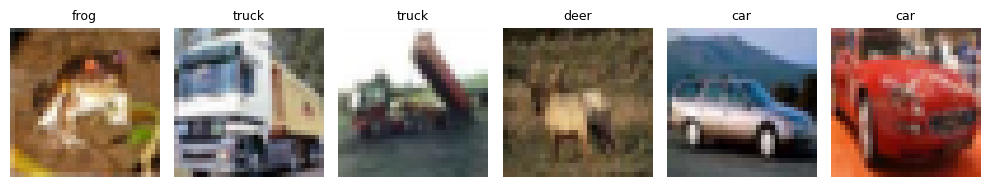

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    img, label = train_set[i]
    img = img * 0.5 + 0.5  # undo normalization
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(classes[label], fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 3. Define the Model


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Training

Epoch [1/10] - Loss: 1.3688
Epoch [2/10] - Loss: 1.0174
Epoch [3/10] - Loss: 0.8780
Epoch [4/10] - Loss: 0.7811
Epoch [5/10] - Loss: 0.7015
Epoch [6/10] - Loss: 0.6277
Epoch [7/10] - Loss: 0.5627
Epoch [8/10] - Loss: 0.5050
Epoch [9/10] - Loss: 0.4435
Epoch [10/10] - Loss: 0.3923


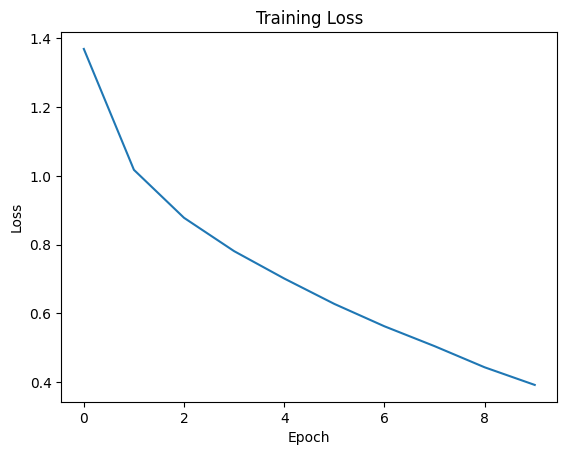

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
for epoch in range(10):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/10] - Loss: {avg_loss:.4f}')

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

## 5. Evaluate

In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f'Test Accuracy: {correct/total:.4f}')

Test Accuracy: 0.6774
